# imports

In [1]:
# imports

import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn

pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

/home/mijka/.pyenv/versions/3.8.12/envs/lewagon_current/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
imp_med = SimpleImputer(missing_values=np.nan, strategy='median')
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

In [3]:
path = './data/'
csv_path = path + 'to_input_openfoodfacts.csv'
sm_df = pd.read_csv(csv_path, low_memory=False)

# Dataframe info

## functions

In [13]:
def get_df_columns_na(df):
    counts = df.isna().sum()
    percentages = round(df.isna().mean() * 100, 1)
    null_values = pd.concat([counts, percentages], axis = 1, keys = ["count", "null_percent"])
    null_values['columns'] = null_values.index
    null_values = null_values[['columns', 'count', 'null_percent']]
    return null_values

In [14]:
def plot_df_xy(df, x_val, y_val, height_val = 20, width_val = 13):
    sns.catplot(data=df, x= x_val, y= y_val, kind="bar", height=height_val, aspect=width_val/height_val)
    sns.set(rc={'figure.figsize':(width_val,height_val)})
    plt.xticks(rotation=70)
    plt.tight_layout()

In [15]:
def show_nulls(df):
    top_sm_df_sort = get_df_columns_na(df).sort_values(by='null_percent',ascending=False)
    print(top_sm_df_sort)
    return plot_df_xy(top_sm_df_sort.reset_index(), 'null_percent', 'columns', 8)

## Infos 

In [17]:
sm_df.head()

,product_name,pnns_groups_1,pnns_groups_2,code,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,L.casei,unknown,unknown,00000000000003429145,NaN,1.4,0.9,9.8,9.80,2.7,0.1,0.04
1,Filetes de pollo empanado,unknown,unknown,000000000003327986,163.9,1.9,1.0,NaN,NaN,15.3,1.1,0.44
2,Burger Meat Pollo,unknown,unknown,000000000004128579,194.0,11.0,3.9,5.7,0.05,18.0,NaN,NaN
3,Hamburguesas de ternera 100%,unknown,unknown,000000000004622327,874.9,15.1,6.1,2.6,1.00,15.7,2.1,0.84
4,moutarde au moût de raisin,Fat and sauces,Dressings and sauces,0000000000100,NaN,8.2,2.2,29.0,22.00,5.1,4.6,1.84


In [11]:
sm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1361912 entries, 0 to 1361911
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   product_name        1361912 non-null  object 
 1   pnns_groups_1       1361912 non-null  object 
 2   pnns_groups_2       1361912 non-null  object 
 3   code                1361912 non-null  object 
 4   energy-kcal_100g    1273181 non-null  float64
 5   fat_100g            1301039 non-null  float64
 6   saturated-fat_100g  1276510 non-null  float64
 7   carbohydrates_100g  1301962 non-null  float64
 8   sugars_100g         1291669 non-null  float64
 9   proteins_100g       1312137 non-null  float64
 10  salt_100g           1204825 non-null  float64
 11  sodium_100g         1205415 non-null  float64
dtypes: float64(8), object(4)
memory usage: 124.7+ MB


In [18]:
sm_df.describe()

,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
count,1.273181e+06,1.301039e+06,1.276510e+06,1.301962e+06,1.291669e+06,1.312137e+06,1.204825e+06,1.205415e+06
mean,2.017106e+02,9.733119e+00,3.567546e+00,1.746357e+01,4.966224e+00,9.132162e+00,1.265053e+00,5.278156e-01
std,1.573178e+02,1.302372e+01,5.959421e+00,2.139302e+01,8.085940e+00,1.050464e+01,2.779495e+00,1.498138e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.700000e+01,5.000000e-01,1.000000e-02,1.900000e+00,4.500000e-01,1.000000e+00,9.000000e-02,3.600000e-02
50%,1.730000e+02,4.100000e+00,1.000000e+00,8.750000e+00,1.900000e+00,5.952381e+00,7.225000e-01,2.900000e-01
75%,3.180000e+02,1.400000e+01,4.200000e+00,2.450000e+01,5.900000e+00,1.400000e+01,1.500000e+00,6.000000e-01
max,8.995633e+02,9.999000e+01,9.990000e+01,9.996000e+01,9.990000e+01,9.990000e+01,7.142750e+01,9.398000e+01


In [20]:
#sm_df.isna().sum()

                               columns   count  null_percent
salt_100g                    salt_100g  157087          11.5
sodium_100g                sodium_100g  156497          11.5
energy-kcal_100g      energy-kcal_100g   88731           6.5
saturated-fat_100g  saturated-fat_100g   85402           6.3
sugars_100g                sugars_100g   70243           5.2
fat_100g                      fat_100g   60873           4.5
carbohydrates_100g  carbohydrates_100g   59950           4.4
proteins_100g            proteins_100g   49775           3.7
product_name              product_name       0           0.0
pnns_groups_1            pnns_groups_1       0           0.0
pnns_groups_2            pnns_groups_2       0           0.0
code                              code       0           0.0


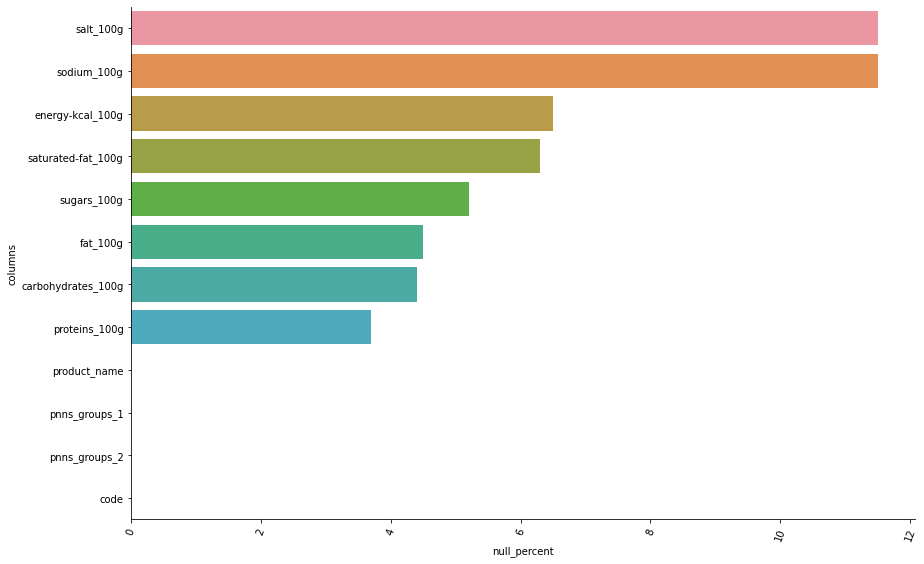

In [19]:
show_nulls(sm_df)

# Inputing

## categories

## numerical values

In [4]:
### appliquer imputer différentes strategies (check distribution) avec un groupby categories
### iterative imputer / estimation du choix d'imputer selon la distribution (mean/median/most frequent...)


In [5]:
sm_df.head()

,product_name,pnns_groups_1,pnns_groups_2,code,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,L.casei,unknown,unknown,00000000000003429145,NaN,1.4,0.9,9.8,9.80,2.7,0.1,0.04
1,Filetes de pollo empanado,unknown,unknown,000000000003327986,163.9,1.9,1.0,NaN,NaN,15.3,1.1,0.44
2,Burger Meat Pollo,unknown,unknown,000000000004128579,194.0,11.0,3.9,5.7,0.05,18.0,NaN,NaN
3,Hamburguesas de ternera 100%,unknown,unknown,000000000004622327,874.9,15.1,6.1,2.6,1.00,15.7,2.1,0.84
4,moutarde au moût de raisin,Fat and sauces,Dressings and sauces,0000000000100,NaN,8.2,2.2,29.0,22.00,5.1,4.6,1.84


In [6]:
main_cats = sm_df['pnns_groups_1'].unique()
main_cats

array(['unknown', 'Fat and sauces', 'Composite foods', 'Sugary snacks',
       'Fruits and vegetables', 'Milk and dairy products',
       'Fish Meat Eggs', 'Cereals and potatoes', 'Salty snacks',
       'Beverages', 'Alcoholic beverages'], dtype=object)

In [7]:
sm_df['pnns_groups_1'].value_counts()

unknown                    818399
Fish Meat Eggs              98519
Milk and dairy products     92960
Cereals and potatoes        70910
Beverages                   63429
Fat and sauces              57575
Composite foods             54347
Fruits and vegetables       44640
Sugary snacks               31421
Salty snacks                24831
Alcoholic beverages          4881
Name: pnns_groups_1, dtype: int64

In [8]:
all_cats = sm_df['pnns_groups_1'].unique().tolist()
all_cats

['unknown',
 'Fat and sauces',
 'Composite foods',
 'Sugary snacks',
 'Fruits and vegetables',
 'Fish Meat Eggs',
 'Beverages',
 'Milk and dairy products',
 'Cereals and potatoes',
 'Salty snacks',
 'Alcoholic beverages',
 nan,
 'sugary-snacks']

In [9]:
all_cols = sm_df.columns
all_cols

Index(['product_name', 'pnns_groups_1', 'pnns_groups_2', 'code',
       'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g'],
      dtype='object')

In [10]:
main_cats = ['fat_100g', 'salt_100g']
complementary_cats = ['saturated-fat_100g','sodium_100g']

In [11]:
final_cats = [c for c in all_cols if c not in main_cats+complementary_cats]
final_cats

['product_name',
 'pnns_groups_1',
 'pnns_groups_2',
 'code',
 'energy-kcal_100g',
 'carbohydrates_100g',
 'sugars_100g',
 'proteins_100g']

In [12]:
all_cols

Index(['product_name', 'pnns_groups_1', 'pnns_groups_2', 'code',
       'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g'],
      dtype='object')

## knn_inputing categories

## main_cats : fat / salt => mean input

In [13]:
#groupby pnns_groups_1, mean, remplir avec mean / categorie
#list1 = ["fat_100g", "salt_100g"]
main_cats

['fat_100g', 'salt_100g']

In [14]:
#main_cats_grp = main_cats.append('pnns_group_1')
#main_cats_grp

In [15]:
#main_cats_grp = ['fat_100g', 'salt_100g', 'pnns_group_1']
#main_cats_grp

In [16]:
# sm_df[[c for c in df.columns if c in main_cats]].head()

In [17]:
sm_df.filter(main_cats).head()

,fat_100g,salt_100g
0,NaN,NaN
1,1.4,0.1
2,NaN,NaN
3,1.9,1.1
4,11.0,NaN


In [18]:
sm_df_groupby = sm_df.groupby(by='pnns_groups_1')

In [19]:
sm_df_groupby.mean()

,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
pnns_groups_1,,,,,,,,
Alcoholic beverages,66.619878,1.290206,0.267635,7.864081,3.626928,1.400195,0.469999,0.215946
Beverages,48.412283,0.820464,0.429246,8.329317,7.094946,0.954389,0.206885,0.092242
Cereals and potatoes,294.311534,4.684030,1.020387,51.001032,3.002433,10.050230,0.682527,0.274646
Composite foods,177.046995,7.539578,2.491210,18.182893,2.565496,7.652201,1.180105,0.473079
Fat and sauces,228.787619,16.480630,4.785741,10.546215,7.180036,1.967222,2.017257,0.811976
Fish Meat Eggs,207.257507,12.748846,4.186412,2.691659,0.896183,18.925177,1.933769,0.776386
Fruits and vegetables,71.978922,1.486411,0.331087,11.226577,6.711564,2.065463,0.515616,0.208700
Milk and dairy products,223.447365,15.633708,10.129301,7.687872,5.959879,12.292904,0.873741,0.363899
Salty snacks,379.848515,29.337939,6.329597,18.591729,1.903797,8.434855,1.660792,0.667126


In [20]:
sm_df.columns

Index(['product_name', 'pnns_groups_1', 'pnns_groups_2', 'code',
       'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g'],
      dtype='object')

In [21]:
sm_df_groupby[main_cats].mean()

,fat_100g,salt_100g
pnns_groups_1,,
Alcoholic beverages,1.290206,0.469999
Beverages,0.820464,0.206885
Cereals and potatoes,4.684030,0.682527
Composite foods,7.539578,1.180105
Fat and sauces,16.480630,2.017257
Fish Meat Eggs,12.748846,1.933769
Fruits and vegetables,1.486411,0.515616
Milk and dairy products,15.633708,0.873741
Salty snacks,29.337939,1.660792


In [22]:
sm_df_groupby[main_cats].count()

,fat_100g,salt_100g
pnns_groups_1,,
Alcoholic beverages,2135,2870
Beverages,61924,60627
Cereals and potatoes,70277,66612
Composite foods,54068,53594
Fat and sauces,50769,56050
Fish Meat Eggs,97356,96129
Fruits and vegetables,43813,42598
Milk and dairy products,92412,89970
Salty snacks,24609,24241


In [23]:
# https://pandas.pydata.org/docs/user_guide/groupby.html

sm_df[main_cats] = sm_df_groupby[main_cats].transform(lambda x: x.fillna(x.mean()))

In [24]:
sm_df.isna().sum()

product_name               0
pnns_groups_1              3
pnns_groups_2              1
code                       0
energy-kcal_100g      434849
fat_100g                   5
saturated-fat_100g    431520
carbohydrates_100g    406068
sugars_100g           416361
proteins_100g         395893
salt_100g                  5
sodium_100g           502615
dtype: int64

In [54]:
sm_df_gr_transf = sm_df_groupby[main_cats].transform(lambda x: x.fillna(x.mean()))
sm_df_gr_transf

,fat_100g,salt_100g
0,9.47151,1.386422
1,1.40000,0.100000
2,9.47151,1.386422
3,1.90000,1.100000
4,11.00000,1.386422
...,...,...
1708025,12.00000,1.000000
1708026,9.47151,1.386422
1708027,9.47151,1.386422
1708028,0.30000,0.640000


In [ ]:
grouped.transform(lambda x: x.fillna(inplace=False))

In [44]:
sm_df.isna().sum()

product_name               0
pnns_groups_1              3
pnns_groups_2              1
code                       0
energy-kcal_100g      434849
fat_100g              406991
saturated-fat_100g    431520
carbohydrates_100g    406068
sugars_100g           416361
proteins_100g         395893
salt_100g             503205
sodium_100g           502615
dtype: int64

In [57]:
sm_df_groupby[main_cats]

In [21]:
## faire fonction et apply par ligne ou boucler sur données uniques

In [61]:
sm_df_main_mean = sm_df_groupby[main_cats].mean()
sm_df_main_mean

,fat_100g,salt_100g
pnns_groups_1,,
Alcoholic beverages,1.290206,0.469999
Beverages,0.820464,0.206885
Cereals and potatoes,4.684030,0.682527
Composite foods,7.539578,1.180105
Fat and sauces,16.480630,2.017257
Fish Meat Eggs,12.748846,1.933769
Fruits and vegetables,1.486411,0.515616
Milk and dairy products,15.633708,0.873741
Salty snacks,29.337939,1.660792


In [59]:
sm_df.head()

,product_name,pnns_groups_1,pnns_groups_2,code,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,jeunes pousses,unknown,unknown,00000000000000225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,L.casei,unknown,unknown,00000000000003429145,NaN,1.4,0.9,9.8,9.80,2.7,0.1,0.04
2,Cacao,unknown,unknown,0000000000031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Filetes de pollo empanado,unknown,unknown,000000000003327986,163.9,1.9,1.0,NaN,NaN,15.3,1.1,0.44
4,Burger Meat Pollo,unknown,unknown,000000000004128579,194.0,11.0,3.9,5.7,0.05,18.0,NaN,NaN


In [66]:
sm_df_main_mean['fat_100g']

pnns_groups_1
Alcoholic beverages         1.290206
Beverages                   0.820464
Cereals and potatoes        4.684030
Composite foods             7.539578
Fat and sauces             16.480630
Fish Meat Eggs             12.748846
Fruits and vegetables       1.486411
Milk and dairy products    15.633708
Salty snacks               29.337939
Sugary snacks               7.797832
sugary-snacks                    NaN
unknown                     9.471510
Name: fat_100g, dtype: float64

In [78]:
import math

def fill_grp_fat(row):
    if math.isnan(row['fat_100g']):
        cat = row['pnns_groups_1']
        print(cat)
        return sm_df_main_mean['fat_100g'][cat]
    else:
        return row['fat_100g']

In [81]:
#sm_df['pnns_groups_1'].value_counts()

In [79]:
sm_df['fat_100g'] = sm_df.apply(lambda x : fill_grp_fat(x), axis=1)

unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fish Meat Eggs
Sugary snacks
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Beverages
Milk and dairy products
Sugary snacks
unknown
unknown
Fish Meat Eggs
unknown
unknown
Sugary snacks
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fruits and vegetables
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fruits and vegetables
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Sugary snacks
Sugary snacks
unknown
unknown
unknown
unknown
unknown
Fat and sauces
unknown
Sugary snacks
unknown
unknown
unknown
unknown
Cereals and potatoes
unknown
unknown
Milk and dairy products
unknown
unknown
unkn

unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Cereals and potatoes
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
unknown
Fat and sauces
unknown
Fat and sauces
Fat and sauces
unknown
unknown
unknown
unknown
Fat and sauces
Fat and sauces
unknown
Fat and sauces
Fat and sauces
unknown
unknown
unknown
unknown
unknown
unknown
Fat and sauces
Fat and sauces
unknown
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
unknown
unknown
unknown
unknown
Fat and sauces
Fat and sauces
Fat and sauces
unknown
Milk and dairy products
unknown
unknown
unknown
unknown
unknown
Fat and sauces
unknown
Fat and sauces
unknown
Beverages
unknown
Fat and sauces
unknown
Fa

unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Sugary snacks
unknown
Cereals and potatoes
Cereals and potatoes
unknown
unknown
Sugary snacks
Cereals and potatoes
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Sugary snacks
Cereals and potatoes
Cereals and potatoes
Cereals and potatoes
Cereals and potatoes
Cereals and potatoes
unknown
unknown
unknown
unknown
Sugary snacks
unknown
unknown
unknown
Milk and dairy products
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Salty snacks
unknown
unknown
unknown
unknown
unknown
unknown
Composite foods
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Milk and dairy products
unknown
Milk and dairy products
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fis

unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fruits and vegetables
unknown
unknown
unknown
Fruits and vegetables
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Beverages
unknown
unknown
unknown
Fat and sauces
unknown
unknown
unknown
unknown
Alcoholic beverages
unknown
Cereals and potatoes
unknown
Milk and dairy products
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fruits and vegetables
Fruits and vegetables
Fruits and vegetables
unknown
Fruits and vegetables
unknown
Fruits and vegetables
unknown
unknown
unknown
unknown
Sugary snacks
unknown
unknown
unknown
unknow

unknown
unknown
unknown
unknown
unknown
Fat and sauces
Sugary snacks
Fruits and vegetables
unknown
unknown
unknown
unknown
unknown
unknown
Salty snacks
Salty snacks
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Salty snacks
unknown
Salty snacks
unknown
unknown
unknown
unknown
Salty snacks
Salty snacks
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Salty snacks
Salty snacks
unknown
Salty snacks
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fat and sauces
unknown
u

...

unknown
Fish Meat Eggs
Fish Meat Eggs
Fish Meat Eggs
unknown
Fish Meat Eggs
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fish Meat Eggs
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fish Meat Eggs
unknown
Fish Meat Eggs
Fish Meat Eggs
unknown
Fish Meat Eggs
Fish Meat Eggs
unknown
Fish Meat Eggs
Fish Meat Eggs
Fish Meat Eggs
Fish Meat Eggs
unknown
Fish Meat Eggs
unknown
unknown
unknown
Fish Meat Eggs
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fat and sauces
Salty snacks
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fat and sauces
unknown
unknown
unknown
unknown
Composite foods
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fish Meat Eggs
Fish Meat Eggs
unknown
unknown
unknown
Fish Meat Eggs
unknown
unknown
unknown
unknown
Fish Meat Eggs
unknown
unknown
unknown
unknown
Sugary snacks
unknown
unknown
Sugary snacks
unkno

unknown
unknown
Fruits and vegetables
unknown
unknown
unknown
unknown
Cereals and potatoes
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fruits and vegetables
Fruits and vegetables
unknown
Fat and sauces
unknown
Sugary snacks
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Cereals and potatoes
unknown
unknown
Fish Meat Eggs
unknown
unknown
unknown
Composite foods
unknown
unknown
Fruits and vegetables
unknown
unknown
unknown
unknown
unknown
Sugary snacks
unknown
unknown
Fat and sauces
Fat and sauces
Composite foods
unknown
unknown
unknown
unknown
unknown
Fruits and vegetables
unknown
unknown
Fish Meat Eggs
unknown
unknown
unknown
unknown
Fish Meat Eggs
unknown
unknown
unknown
unknown
Fish Meat Eggs
Fish Meat Eggs
Fish Meat Eggs
Fish Meat Eggs
Fish Meat Eggs
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown

unknown
unknown
unknown
Fat and sauces
Fat and sauces
unknown
Fat and sauces
Fruits and vegetables
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Alcoholic beverages
Alcoholic beverages
Alcoholic beverages
Alcoholic beverages
unknown
unknown
unknown
unknown
unknown
Alcoholic beverages
Alcoholic beverages
unknown
Composite foods
unknown
unknown
unknown
unknown
unknown
Cereals and potatoes
Cereals and potatoes
Cereals and potatoes
unknown
Fat and sauces
Fruits and vegetables
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fat and sauces
Cereals and potatoes
unknown
unknown
unknown
Milk and dairy products
unknown
Fat and sauces
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fish Meat Eggs
Fish Meat Eggs
Fish Meat Eggs
unknown
Fish Meat Eggs
unknown
Fish Meat Eggs
Milk and dairy products
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Milk and dairy products
unknown
unknown
unk

unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Sugary snacks
unknown
unknown
unknown
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
Fat and sauces
unknown
unknown
Sugary snacks
unknown
unknown
unknown
Fat and sauces
unknown
Fruits and vegetables
unknown
unknown
Sugary snacks
unknown
unknown
unknown
unknown
Beverages
Sugary snacks
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Composite foods
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
Fish Meat Eggs
unknown
Fat and sauces
unknown
Composite foods
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown
unknown


KeyError: nan

In [22]:
## utiliser index (str) de sm_df_groupby

In [23]:
#sm_df.filter(main_cats_grp).head()

## compl_cats : sat_fat / sodium => linearRegression

In [24]:
# IterativeImputer avec estimator=LinearRegression()
#list2 = ["saturated-fat_100g", "sodium_100g"] 
complementary_cats

['saturated-fat_100g', 'sodium_100g']

In [25]:
sm_df.filter(complementary_cats).head()

,saturated-fat_100g,sodium_100g
0,NaN,NaN
1,0.9,0.04
2,NaN,NaN
3,1.0,0.44
4,3.9,NaN


In [26]:
#sm_df_groupby.median().columns

In [27]:
#sm_df_groupby.median()

In [31]:
sm_df_groupby[complementary_cats].median()

,saturated-fat_100g,sodium_100g
pnns_groups_1,,
Alcoholic beverages,0.00,0.000000
Beverages,0.00,0.004000
Cereals and potatoes,0.40,0.180000
Composite foods,1.79,0.390000
Fat and sauces,1.10,0.520000
Fish Meat Eggs,2.68,0.640000
Fruits and vegetables,0.00,0.066040
Milk and dairy products,8.47,0.140000
Salty snacks,3.50,0.520000


## final_cats => 

In [29]:
final_cats

['product_name',
 'pnns_groups_1',
 'pnns_groups_2',
 'code',
 'energy-kcal_100g',
 'carbohydrates_100g',
 'sugars_100g',
 'proteins_100g']

In [30]:
#Reste des variables contenant des valeurs vides (sans list1, list2,  pnns_groups_1, pnns_groups_2) : 
# remplir soit avec la moyenne soit avec la mediane, en fonction de la distribution 
#- remplir avec la valeur la plus fréquente


In [ ]:
#imp_med = SimpleImputer(missing_values=np.nan, strategy='median')

###sm_df[all_num_cols] = imp_med.fit_transform(sm_df[all_num_cols])